In [58]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GH_TOKEN')

In [59]:
!git clone https://{GITHUB_TOKEN}@github.com/Aliaa-mohamed47/face-mask-detection.git

fatal: destination path 'face-mask-detection' already exists and is not an empty directory.


In [60]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from PIL import Image
import os
import random

In [61]:
# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load dataset
test_dataset = datasets.ImageFolder("face-mask-detection/data/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = test_dataset.classes
print("Classes:", class_names)

Classes: ['WithMask', 'WithoutMask']


In [62]:
model = models.mobilenet_v2(weights=None)

# Modify classifier
model.classifier[1] = nn.Linear(model.last_channel, len(class_names))

# Load weights
model.load_state_dict(torch.load("face-mask-detection/model/mask_detector.pth", map_location='cpu'))

model.eval()

print("Model loaded successfully ")

Model loaded successfully 


In [63]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction done ")

Prediction done 


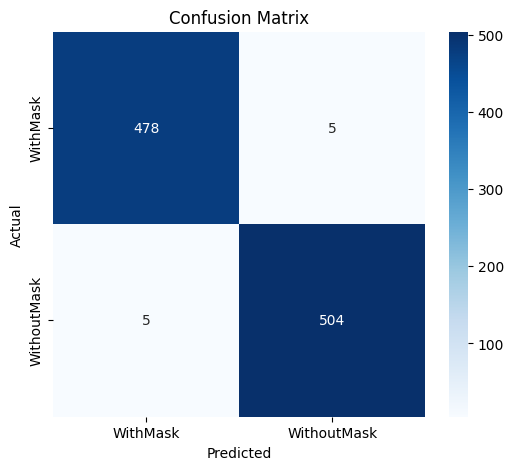

In [64]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [65]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    WithMask       0.99      0.99      0.99       483
 WithoutMask       0.99      0.99      0.99       509

    accuracy                           0.99       992
   macro avg       0.99      0.99      0.99       992
weighted avg       0.99      0.99      0.99       992



In [66]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9899193548387096


In [67]:
wrong_indices = np.where(y_true != y_pred)[0]
print("Number of wrong predictions:", len(wrong_indices))

Number of wrong predictions: 10


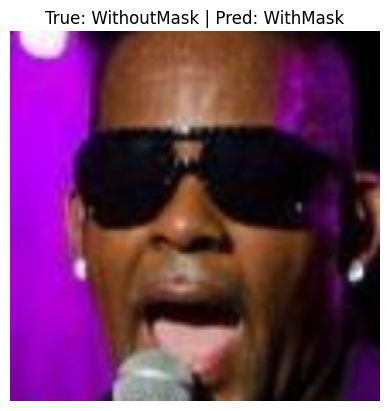

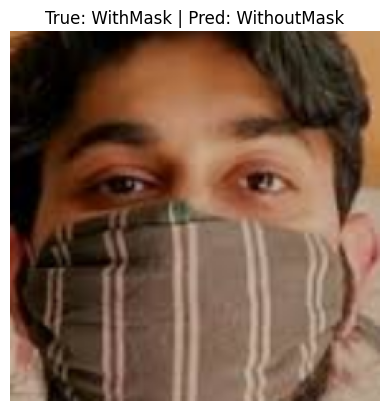

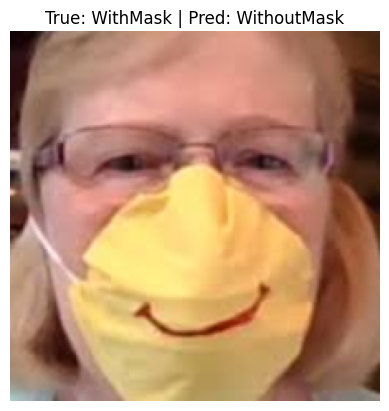

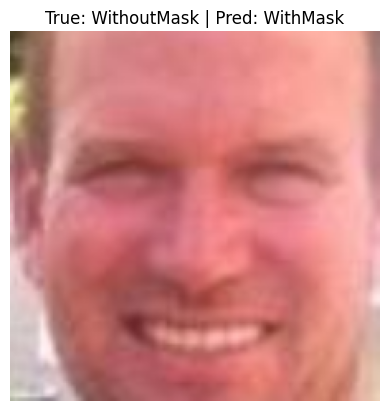

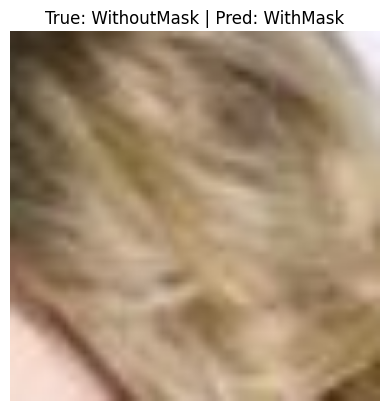

In [72]:
mean_vals = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_vals = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in random.sample(list(wrong_indices), min(5, len(wrong_indices))):
    img, label = test_dataset[i]

    # Un-normalize the image for display
    img_display = img * std_vals + mean_vals
    img_display = torch.clamp(img_display, 0, 1) # Clip to [0, 1] range

    plt.imshow(img_display.permute(1,2,0))
    plt.title(f"True: {class_names[label]} | Pred: {class_names[y_pred[i]]}")
    plt.axis('off')
    plt.show()

In [69]:
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    return class_names[pred.item()]

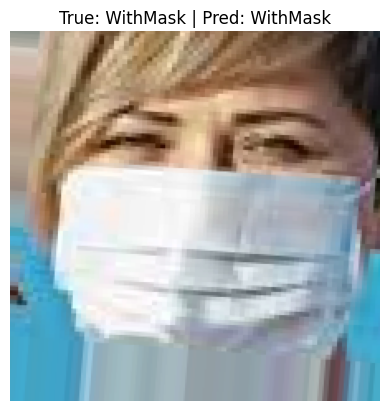

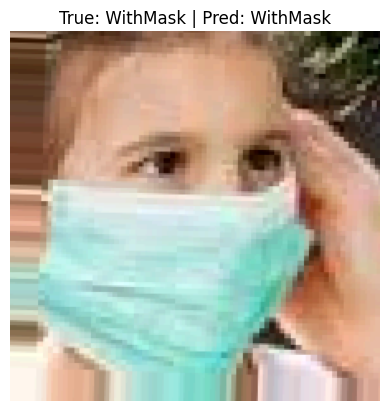

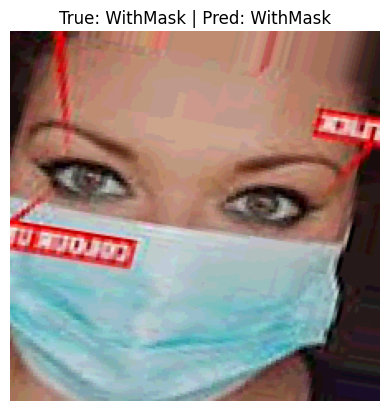

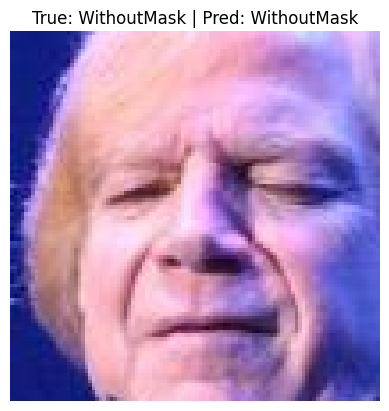

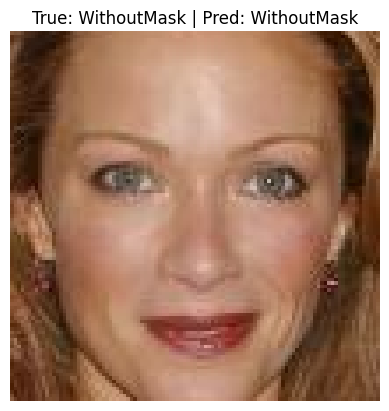

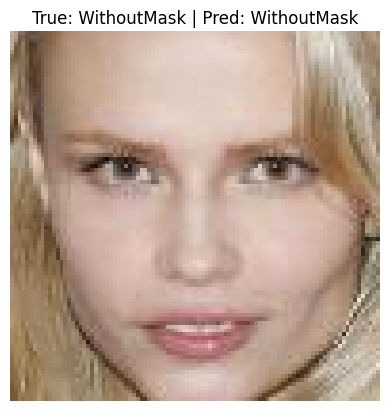

In [70]:
test_images_path = "face-mask-detection/data/test"

samples = []

for class_name in class_names:
    class_folder = os.path.join(test_images_path, class_name)
    images = os.listdir(class_folder)

    for img in random.sample(images, min(3, len(images))):
        samples.append((os.path.join(class_folder, img), class_name))

for path, true_label in samples:
    pred = predict_image(path)

    img = Image.open(path)

    plt.imshow(img)
    plt.title(f"True: {true_label} | Pred: {pred}")
    plt.axis('off')
    plt.show()